In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# semi colons used to seperate text.
# european dataset so comma is used rather than decimal place

df = pd.read_csv('../data/raw/LD2011_2014.txt', sep=';', decimal=',')

Deal with data type issues and getting of datetime column

In [4]:
print('shape before changes:', df.shape)

# convert commas to decimal places in final column
df['MT_362'] = df['MT_362'].replace(',', '.').astype(np.float64)

# rename first column to datetime
df.rename(columns={'Unnamed: 0': 'datetime'}, inplace=True)

# now convert the new column to datetime format
df['datetime'] = pd.to_datetime(df['datetime'])

print('shape after changes:', df.shape)

shape before changes: (140256, 371)
shape after changes: (140256, 371)


In [5]:
# see what max values are

df['MT_196'].describe().T

count    140256.000000
mean      20744.150874
std        7339.107947
min           0.000000
25%       15208.333333
50%       20583.333333
75%       25208.333333
max       78541.666667
Name: MT_196, dtype: float64

In [ ]:
print('hours in use: \n', df['datetime'].apply(lambda x: x.hour).value_counts(), '\n')
print('minutes in use: \n', df['datetime'].apply(lambda x: x.minute).value_counts(), '\n')
print('days in use: \n', df['datetime'].apply(lambda x: x.day).value_counts(), '\n')
# there is an equal number of points for each hour in the dataset as would expect where data has complete days only
# same with minutes
# overall number of date vars are correct
# however time change days in October will have anomalous usage
# NOTE: look into later. From graph analysis (below) - does not seem to have visually noticable effect upon usage but
# come back to check later
# also doesn't seem to be consistent change sin usage on March time change day either. Many places usage 
# does not go to zero. Suggests already dealt with. Come back to later

hours in use: 
 datetime
0     5844
1     5844
22    5844
21    5844
20    5844
19    5844
18    5844
17    5844
16    5844
15    5844
14    5844
13    5844
12    5844
11    5844
10    5844
9     5844
8     5844
7     5844
6     5844
5     5844
4     5844
3     5844
2     5844
23    5844
Name: count, dtype: int64 

minutes in use: 
 datetime
15    35064
30    35064
45    35064
0     35064
Name: count, dtype: int64 

days in use: 
 datetime
1     4608
2     4608
28    4608
27    4608
26    4608
25    4608
24    4608
23    4608
22    4608
21    4608
20    4608
19    4608
18    4608
17    4608
16    4608
15    4608
14    4608
13    4608
12    4608
11    4608
10    4608
9     4608
8     4608
7     4608
6     4608
5     4608
4     4608
3     4608
29    4320
30    4224
31    2688
Name: count, dtype: int64 



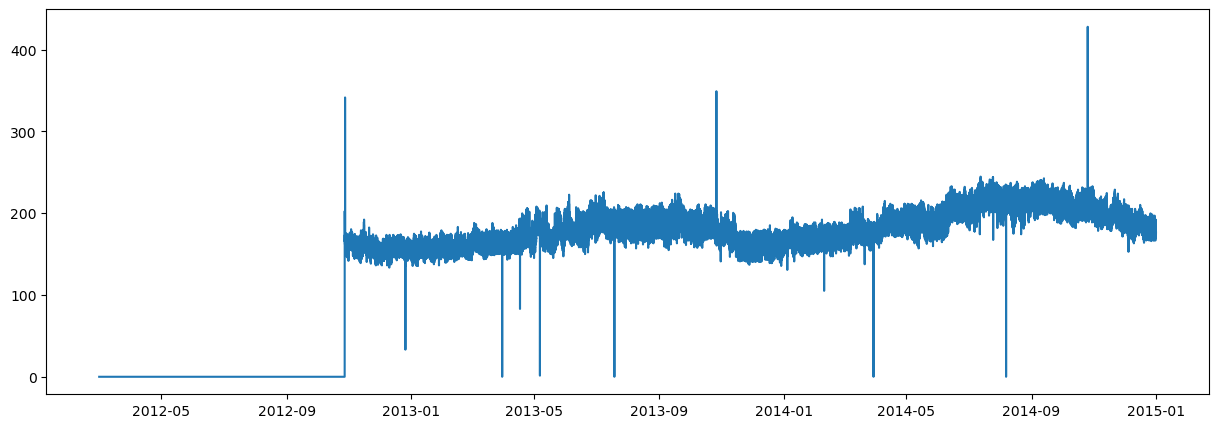

In [65]:
quarters_in_year = 4*24*365
starting_quarter = 1*quarters_in_year + 4*24*60
years_to_plot = 4
datetime_range_to_plot = df['datetime'].iloc[int(starting_quarter): int(starting_quarter) + int(years_to_plot*quarters_in_year)]
hourly_data_to_plot = df['MT_144'].iloc[int(starting_quarter): int(starting_quarter) + int(years_to_plot*quarters_in_year)]


plt.figure(figsize=(15, 5))
plt.plot(datetime_range_to_plot, hourly_data_to_plot)
plt.show()
# can see seasonal trend but that nearer end of series, get bump in usage
# customers that don't have data straight away seem to have a clean start at the start of the year

# can see periodic dip around MArch for the time change day. For now will ignore as 

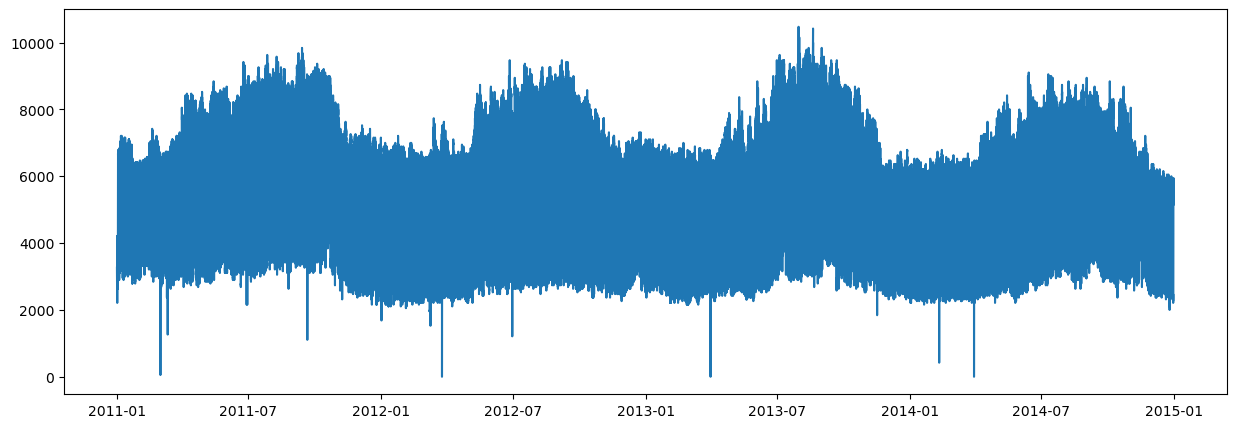

In [25]:
quarters_in_year = 4*24*365
starting_quarter = 0#1*quarters_in_year + 4*24*60
years_to_plot = 4
datetime_range_to_plot = df['datetime'].iloc[int(starting_quarter): int(starting_quarter) + int(years_to_plot*quarters_in_year)]
hourly_data_to_plot = df['MT_228'].iloc[int(starting_quarter): int(starting_quarter) + int(years_to_plot*quarters_in_year)]


plt.figure(figsize=(15, 5))
plt.plot(datetime_range_to_plot, hourly_data_to_plot)
plt.show()

In [5]:
# find way to get rid of periods where the client was not a customer at a given point
# could use expanding window, where sum equals zero (with tolerance, then not yet a customer, otherwise they are customer)

# df = df.rolling(window=3).sum()
# for now, condense dataset by getting energy consumed in the previous hour
# first need to convert to Kwh:
df_kwh_adjust = df.copy()

# index using df.columns to change all columns except the datetime. divide by four and sum 
# with previous three rows to get the hourly energy usage in Kwh 
df_kwh_adjust.loc[:, df.columns != 'datetime'] = (df_kwh_adjust.loc[:, df.columns != 'datetime']/4).rolling(window=4).sum()

# now remove nan columns from start of dataset (as none present elsewhere)
df_kwh_adjust.dropna(axis=0, inplace=True)

In [6]:
# and only maintain hourly data for the time being (to condense for now)
# need to use datetime accessor to get the date attributes
df_hourly_data = df_kwh_adjust[df_kwh_adjust['datetime'].dt.minute == 0]

# df_hourly_data
# df_kwh_adjust['datetime'].dt.minute.apply(lambda x: type(x))

Just plot all data for individual stations

In [52]:
hours_in_year = 24*365
starting_hour = hours_in_year*1.5
years_to_plot = 0.02
# years_to_plot = 4
datetime_range_to_plot = df_hourly_data['datetime'].iloc[int(starting_hour): int(starting_hour + years_to_plot*hours_in_year)]
hourly_data_to_plot = df_hourly_data['MT_132'].iloc[int(starting_hour): int(starting_hour + years_to_plot*hours_in_year)]

hourly_data_to_plot[hourly_data_to_plot < 2]
# plt.figure(figsize=(15, 5))
# plt.plot(datetime_range_to_plot, hourly_data_to_plot)
# plt.show()
# can see seasonal trend but that nearer end of series, get bump in usage
# customers that don't have data straight away seem to have a clean start at the start of the year

# can see periodic dip around MArch for the time change day

52639    0.0
52643    0.0
52647    0.0
52651    0.0
52655    0.0
        ... 
53071    0.0
53075    0.0
53079    0.0
53083    0.0
53087    0.0
Name: MT_132, Length: 93, dtype: float64

In [35]:
# now to reorientate data so that have datetime and the client id (initially columns) as row definers
df_melted = df_hourly_data.melt(id_vars=['datetime'])
# and rename columns so more meaningful
df_melted.rename(columns={'variable': 'client_id',
                          'value': 'hourly_usage_kwh'}, inplace=True)

# convert client id to integer (i.e., remove letters) (TODO: this operation inefficient but fine for EDA here)
df_melted['client_id'] = df_melted['client_id'].apply(lambda str: np.int64(str.replace('MT_', '')))

In [36]:
# for now, remove the data where they were not a customer
# deifne using expanding window and sum. Where expanding sum equal zero, presumed that not yet a customer
# note that need to window while partitioning by the 

# get cumulative usage
df_melted['cumsum_usage'] = df_melted.groupby('client_id')['hourly_usage_kwh'].transform('cumsum')

In [37]:

print('shape before clipping', df_melted.shape)
# then use cumulayive usage to remove data. For now keeping simple, 
# removing all rows where the cumulative usage is zero, assuming that all data before is
# because they were not yet a customer (possible that could have been on holiday at data start)
# but data also started in January so considered less likely here. (note employing tolerance)
df_melted_clipped = df_melted[df_melted['cumsum_usage'] > 1e-9]

print('shape after clipping', df_melted_clipped.shape)

# lost around 200000 rows from clipping 

shape before clipping (12973680, 4)
shape after clipping (10484119, 4)


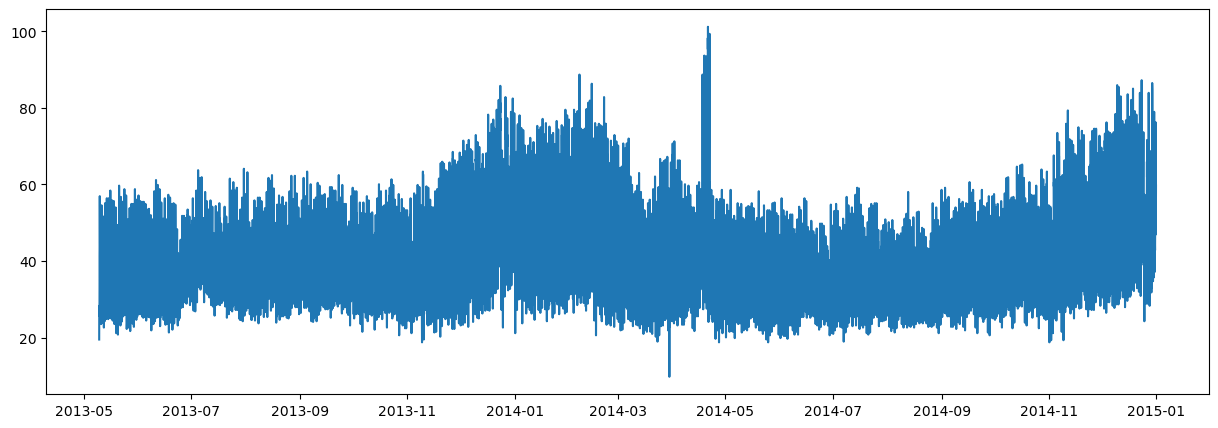

In [179]:
# test plot of usage for one customer over whole of period
starting_hour = 0
hours_in_year = 24*365
years_to_plot = 4
client_to_plot = 30

df_to_plot = df_melted_clipped[df_melted_clipped['client_id'] == client_to_plot]
datetime_range_to_plot = df_to_plot['datetime'].iloc[starting_hour: starting_hour + years_to_plot*hours_in_year]
usage_range_to_plot = df_to_plot['hourly_usage_kwh'].iloc[starting_hour: starting_hour + years_to_plot*hours_in_year]


plt.figure(figsize=(15, 5))
plt.plot(datetime_range_to_plot, usage_range_to_plot)
plt.show()

Test a diurnal average for one client

C:\Users\Flynn\AppData\Local\Temp\ipykernel_18476\3583280196.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_plot['month'] = df_to_plot['datetime'].dt.month
C:\Users\Flynn\AppData\Local\Temp\ipykernel_18476\3583280196.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_plot['day_of_week'] = df_to_plot['datetime'].dt.dayofweek


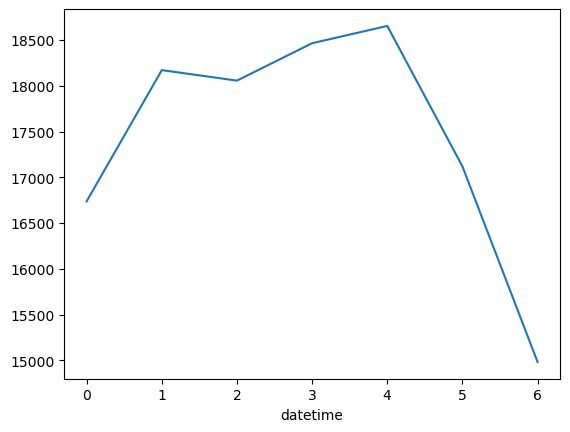

In [ ]:
# test plot of usage for one customer over whole of period
starting_hour = 0
hours_in_year = 24*365
years_to_plot = 4
client_to_plot = 370

df_to_plot = df_melted_clipped[df_melted_clipped['client_id'] == client_to_plot]

# get diurnal profile
# df_to_plot['hour'] = df_to_plot['datetime'].dt.hour
diurnal_avg_usage = df_to_plot.groupby(df_to_plot['datetime'].dt.hour)['hourly_usage_kwh'].mean()

# get monthly profile
df_to_plot['month'] = df_to_plot['datetime'].dt.month
monthly_avg_usage = df_to_plot.groupby('month')['hourly_usage_kwh'].mean()
monthly_avg_usage = df_to_plot.groupby(df_to_plot['datetime'].dt.month)['hourly_usage_kwh'].mean()

# get day of week profile
df_to_plot['day_of_week'] = df_to_plot['datetime'].dt.dayofweek
dayofweek_avg_usage = df_to_plot.groupby(df_to_plot['datetime'].dt.dayofweek)['hourly_usage_kwh'].mean()

# diurnal_avg_usage.plot()
# plt.show()

# monthly_avg_usage.plot()
# plt.show()

dayofweek_avg_usage.plot()
plt.show()

# typically dips in morning, peaks in evening
# seem to be two patterns of monthyl usage. Some peak in late summer (maybe industrial?) - magnitude much larger
# others peak in winter months (likely home users) - magnitude smaller
# some peak on weekends, but not everyone

# final client has huge usage, probably a composite sum of previous clients

In [ ]:
df_melted_clipped[df['client_id'] != 370].groupby('client_id')['hourly_usage_kwh'].first()

client_id
1        1
2        2
3        3
4        4
5        5
      ... 
366    366
367    367
368    368
369    369
370    370
Name: client_id, Length: 370, dtype: int64